In [2]:

    
    # ============================================
# ÉTAPE 1 : IMPORT DES LIBRAIRIES
# ============================================
# On importe tous les outils dont on a besoin

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

print("✅ PyTorch version:", torch.__version__)
print("✅ GPU disponible:", torch.cuda.is_available())

✅ PyTorch version: 2.10.0+cpu
✅ GPU disponible: False


In [3]:
# ============================================
# ÉTAPE 2 : CHEMINS DU DATASET
# ============================================
# On dit à Python où se trouvent les images
# et on compte combien d'images on a par classe

TRAIN_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
TEST_DIR  = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

# Les 4 types de tumeurs que le modèle doit reconnaître
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Compter les images par classe
print("=== TRAINING ===")
for cls in CLASSES:
    path = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(path))
    print(f"  {cls} : {count} images")

print("\n=== TESTING ===")
for cls in CLASSES:
    path = os.path.join(TEST_DIR, cls)
    count = len(os.listdir(path))
    print(f"  {cls} : {count} images")

=== TRAINING ===
  glioma : 1400 images
  meningioma : 1400 images
  notumor : 1400 images
  pituitary : 1400 images

=== TESTING ===
  glioma : 400 images
  meningioma : 400 images
  notumor : 400 images
  pituitary : 400 images


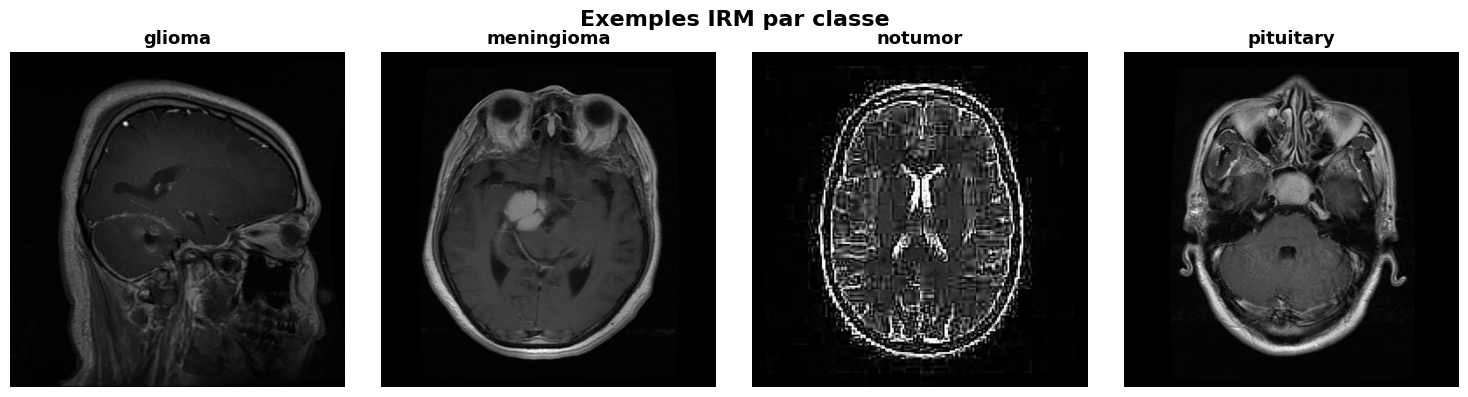

In [4]:
# ============================================
# ÉTAPE 3 : VISUALISATION DES IMAGES
# ============================================
# On affiche des exemples d'images IRM
# pour chaque classe avant de commencer

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
# 1 ligne x 4 colonnes = une image par classe

for i, cls in enumerate(CLASSES):
    
    # Chemin du dossier de cette classe
    class_path = os.path.join(TRAIN_DIR, cls)
    
    # Prendre la première image du dossier
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Ouvrir l'image en niveaux de gris
    # (les IRM sont naturellement en noir et blanc)
    img = Image.open(img_path).convert('L')
    
    # Afficher l'image avec son nom de classe
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls, fontsize=13, fontweight='bold')
    axes[i].axis('off')  # Cacher les axes

plt.suptitle('Exemples IRM par classe', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# ============================================
# ÉTAPE 4 : PRÉPARATION DES DONNÉES
# ============================================
# On prépare les images pour les donner au modèle
# PyTorch ne comprend pas les images directement
# il faut les transformer en tenseurs (tableaux de nombres)

# --- Transformations pour l'entraînement ---
# On ajoute des variations pour que le modèle
# soit plus robuste → technique : data augmentation
train_transform = transforms.Compose([
    # Toutes les images à la même taille : 224x224 pixels
    transforms.Resize((224, 224)),
    # Retourner aléatoirement l'image (comme un miroir)
    transforms.RandomHorizontalFlip(),
    # Rotation aléatoire entre -10° et +10°
    transforms.RandomRotation(10),
    # Convertir l'image en tenseur PyTorch (pixels de 0-255 → 0.0-1.0)
    transforms.ToTensor(),
    # Normaliser les pixels (obligatoire pour ResNet)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Transformations pour le test ---
# Pas de data augmentation ici
# On veut évaluer sur des images normales
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transformations définies !")

# ============================================
# CRÉATION DE LA CLASSE DATASET
# ============================================
# PyTorch a besoin d'une classe Dataset
# pour savoir comment charger UNE image

class BrainTumorDataset(Dataset):
    
    def __init__(self, data_dir, classes, transform=None):
        self.transform = transform
        self.samples = []
        
        # Créer un dictionnaire classe → numéro
        # Ex: {'glioma':0, 'meningioma':1, 'notumor':2, 'pituitary':3}
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        
        # Lister toutes les images avec leur label
        for cls in classes:
            cls_path = os.path.join(data_dir, cls)
            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path, img_name)
                label = self.class_to_idx[cls]
                self.samples.append((img_path, label))
    
    def __len__(self):
        # Retourne le nombre total d'images
        return len(self.samples)
    
    def __getitem__(self, idx):
        # Retourne UNE image et son label
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

print("✅ Classe Dataset définie !")

# --- Créer les datasets ---
train_dataset = BrainTumorDataset(TRAIN_DIR, CLASSES, transform=train_transform)
test_dataset  = BrainTumorDataset(TEST_DIR,  CLASSES, transform=test_transform)

print(f"✅ Dataset entraînement : {len(train_dataset)} images")
print(f"✅ Dataset test         : {len(test_dataset)} images")

# --- Créer les DataLoaders ---
# Charge les images par lots de 32
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"✅ DataLoader entraînement : {len(train_loader)} lots de 32 images")
print(f"✅ DataLoader test         : {len(test_loader)} lots de 32 images")

✅ Transformations définies !
✅ Classe Dataset définie !
✅ Dataset entraînement : 5600 images
✅ Dataset test         : 1600 images
✅ DataLoader entraînement : 175 lots de 32 images
✅ DataLoader test         : 50 lots de 32 images


In [6]:
# ============================================

# ============================================
# ÉTAPE 5 : CONSTRUCTION DU MODÈLE
# ============================================

# --- Choisir CPU ou GPU ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device utilisé : {device}")

# --- Charger ResNet18 SANS téléchargement ---
import torchvision.models as models
from torchvision.models import ResNet18_Weights

# On désactive complètement le téléchargement
import os
os.environ['TORCH_HOME'] = '/kaggle/working'

# Charger sans poids pré-entraînés
model = models.resnet18(weights=None)

# --- Adapter la dernière couche ---
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

# --- Envoyer sur le device ---
model = model.to(device)

print("✅ Modèle ResNet18 créé !")
print(f"✅ Adapté pour {len(CLASSES)} classes : {CLASSES}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Fonction de perte : CrossEntropyLoss")
print("✅ Optimiseur        : Adam (lr=0.001)")

✅ Device utilisé : cpu
✅ Modèle ResNet18 créé !
✅ Adapté pour 4 classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
✅ Fonction de perte : CrossEntropyLoss
✅ Optimiseur        : Adam (lr=0.001)


In [7]:
# ============================================
# ÉTAPE 6 : ENTRAÎNEMENT DU MODÈLE
# ============================================
# On va entraîner le modèle sur 5 époques
# 1 époque = le modèle voit TOUTES les 5600 images une fois

# Nombre de fois qu'on va parcourir tout le dataset
NUM_EPOCHS = 2

print("🚀 Début de l'entraînement...\n")

for epoch in range(NUM_EPOCHS):
    
    # --- Mode entraînement ---
    # Active certaines couches spéciales (Dropout, BatchNorm)
    model.train()
    
    total_loss = 0      # Somme des erreurs
    correct    = 0      # Nombre de bonnes prédictions
    total      = 0      # Nombre total d'images vues
    
    for images, labels in train_loader:
        
        # Envoyer les images et labels sur le device (CPU/GPU)
        images = images.to(device)
        labels = labels.to(device)
        
        # --- Étape 1 : Remettre les gradients à zéro ---
        # (obligatoire sinon PyTorch accumule les gradients)
        optimizer.zero_grad()
        
        # --- Étape 2 : Prédiction du modèle ---
        # Le modèle reçoit les images et prédit les classes
        outputs = model(images)
        
        # --- Étape 3 : Calculer l'erreur ---
        # Comparer les prédictions avec les vraies classes
        loss = criterion(outputs, labels)
        
        # --- Étape 4 : Rétropropagation ---
        # Calculer comment corriger les poids du modèle
        loss.backward()
        
        # --- Étape 5 : Mettre à jour les poids ---
        optimizer.step()
        
        # Accumuler les statistiques
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)
    
    # Calculer la précision de cette époque
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)
    
    print(f"Époque {epoch+1}/{NUM_EPOCHS} → Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("\n✅ Entraînement terminé !")

🚀 Début de l'entraînement...

Époque 1/2 → Loss: 0.7305 | Accuracy: 71.23%
Époque 2/2 → Loss: 0.4945 | Accuracy: 81.34%

✅ Entraînement terminé !


In [8]:
# ============================================
# ÉTAPE 7 : ÉVALUATION DU MODÈLE
# ============================================
# On teste le modèle sur les images de TEST
# Ces images, le modèle ne les a JAMAIS vues
# C'est comme un examen après les révisions

# --- Mode évaluation ---
# On désactive certaines couches (Dropout)
# pour avoir des prédictions stables
model.eval()

correct = 0  # Nombre de bonnes prédictions
total   = 0  # Nombre total d'images testées

# torch.no_grad() = on n'a pas besoin de calculer
# les gradients pendant le test → plus rapide
with torch.no_grad():
    for images, labels in test_loader:
        
        # Envoyer sur le device
        images = images.to(device)
        labels = labels.to(device)
        
        # Prédiction du modèle
        outputs = model(images)
        
        # Prendre la classe avec le score le plus élevé
        _, predicted = torch.max(outputs, 1)
        
        # Compter les bonnes prédictions
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

# Calculer la précision finale
accuracy = 100 * correct / total
print(f"✅ Précision sur le dataset de test : {accuracy:.2f}%")
print(f"✅ Bonnes prédictions : {correct}/{total} images")

✅ Précision sur le dataset de test : 60.62%
✅ Bonnes prédictions : 970/1600 images
